In [1]:
# !pip install -q pandas numpy scikit-learn matplotlib seaborn tensorflow joblib tf2onnx xgboost

In [2]:
import os, json, math, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, f1_score,
                             accuracy_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

from google.colab import files   # uncomment on Colab

In [3]:
uploaded = files.upload()

FILE_NAME = "audit_trail_2025.csv"
df = pd.read_csv(FILE_NAME)
print(f"Loaded {df.shape[0]:,} rows Ã— {df.shape[1]} columns")
df.head()

Saving audit_trail_2025.csv to audit_trail_2025.csv
Loaded 89,633 rows Ã— 30 columns


,id,insuredId,status,sessionId,action,httpCode,ip,userAgent,requestData,requestReturn,...,domainIdList,subType,countryCode,city,month,sessionNumber,sequenceInSession,sessionLength,is_anomaly,anomaly_type
0,4f544f4f-723a-4e09-a641-967d1e22bc0d,18577425,OK,7611514,Connexion en tant que,204,84.104.169.220,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{""login"": ""18577425"", ""channel"": ""web"", ""count...",NaN,...,[10],logging_login_as_insured,NL,Amsterdam,2025-01,5,1,7,0,NaN
1,0ead5ec9-517f-4797-b41a-b47a0fdf3967,18577425,OK,7611514,Changer les coordonnées bancaire,201,84.104.169.220,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{""iban_last4"": ""4354"", ""bic"": ""AGRIFRPP"", ""cou...","{""status"": ""success"", ""reference"": ""REF-590413""}",...,[],NaN,NL,Amsterdam,2025-01,5,2,7,0,NaN
2,47aaecbf-fd5e-49a5-8db6-ad9fd291d27a,95930357,OK,8133683,Connexion,200,86.192.192.203,mobileapp/4.3.0 (ios; build=812; locale=fr-FR),"{""login"": ""95930357"", ""channel"": ""mobile"", ""co...","{""status"": ""success"", ""reference"": ""REF-360603""}",...,[12],logging_login,FR,Marseille,2025-01,5,1,4,0,NaN
3,087f1bfd-6b23-4f60-9489-c10a53f7469a,95930357,OK,8133683,Validation MFA,200,86.192.192.203,mobileapp/4.3.0 (ios; build=812; locale=fr-FR),"{""login"": ""95930357"", ""channel"": ""mobile"", ""co...",NaN,...,[12],logging_mfa_validation,FR,Marseille,2025-01,5,2,4,0,NaN
4,4a6d5b15-245d-4913-84cf-de9939f22c0a,95930357,OK,8133683,Téléchargement carte TP,204,86.192.192.203,mobileapp/4.3.0 (ios; build=812; locale=fr-FR),"{""insuredId"": ""95930357"", ""action"": ""T\u00e9l\...",NaN,...,[12],download_third_party_card,FR,Marseille,2025-01,5,3,4,0,NaN


In [4]:
df["createdAt"] = pd.to_datetime(df["createdAt"], utc=True, errors="coerce")

list_cols = ["companyIdList","companyGroupIdList","insurerIdList",
             "companySectionIdList","insurerCodeIdList",
             "healthcareNetworkIdList","domainIdList"]
for c in list_cols:
    df[c] = df[c].fillna("[]").astype(str)

text_cols = ["action","type","subType","device","countryCode","city","status","userAgent"]
for c in text_cols:
    if c in df.columns:
        df[c] = df[c].fillna("UNKNOWN").astype(str)

if "is_anomaly" not in df.columns:
    df["is_anomaly"] = 0
if "anomaly_type" not in df.columns:
    df["anomaly_type"] = "normal"
df["anomaly_type"] = df["anomaly_type"].replace(r"^\s*$", np.nan, regex=True)
df["anomaly_type"] = df["anomaly_type"].replace("UNKNOWN", np.nan)
df["anomaly_type"] = df["anomaly_type"].fillna("normal").astype(str)
df.loc[df["is_anomaly"] == 0, "anomaly_type"] = "normal"
if "sessionLength" not in df.columns:
    df["sessionLength"] = df.groupby(["insuredId","sessionNumber"])["sequenceInSession"].transform("max")

df = df.sort_values(["insuredId","sessionNumber","sequenceInSession"]).reset_index(drop=True)
print("Normal rows  :", (df["is_anomaly"] == 0).sum())
print("Anomaly rows :", (df["is_anomaly"] == 1).sum())
if df["is_anomaly"].sum() > 0:
    print("Anomaly types:\n", df[df["is_anomaly"]==1]["anomaly_type"].value_counts())

Normal rows  : 85263
Anomaly rows : 4370
Anomaly types:
 anomaly_type
repeated_fail     1050
impossible_seq     912
skip_login         632
rapid_fire         604
geo_jump           596
unusual_hour       576
Name: count, dtype: int64


In [5]:
df["hour"]      = df["createdAt"].dt.hour
df["dayofweek"] = df["createdAt"].dt.dayofweek
df["month_num"] = df["createdAt"].dt.month
df["hour_sin"]  = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"]  = np.cos(2*np.pi*df["hour"]/24)
df["dow_sin"]   = np.sin(2*np.pi*df["dayofweek"]/7)
df["dow_cos"]   = np.cos(2*np.pi*df["dayofweek"]/7)
df["is_ok"] = (df["status"]=="OK").astype(int)
df["is_ko"] = (df["status"]=="KO").astype(int)

In [6]:
action_le  = LabelEncoder()
device_le  = LabelEncoder()
country_le = LabelEncoder()
type_le    = LabelEncoder()
subtype_le = LabelEncoder()

df["action_id"]       = action_le.fit_transform(df["action"])
df["device_id"]       = device_le.fit_transform(df["device"])
df["country_id"]      = country_le.fit_transform(df["countryCode"])
df["type_id"]         = type_le.fit_transform(df["type"])
df["subType_filled"]  = df["subType"].fillna("NONE").astype(str)
df["subtype_id"]      = subtype_le.fit_transform(df["subType_filled"])

print("Unique actions:", len(action_le.classes_))

Unique actions: 43


In [7]:
SESSION_KEY = ["insuredId","sessionNumber"]
df["prev_time"]  = df.groupby(SESSION_KEY)["createdAt"].shift(1)
df["delta_seconds"] = (df["createdAt"]-df["prev_time"]).dt.total_seconds().fillna(0)
df["delta_seconds_clipped"] = df["delta_seconds"].clip(0, 3600)

scaler_delta = StandardScaler()
df["delta_scaled"] = scaler_delta.fit_transform(df[["delta_seconds_clipped"]])

In [8]:
df["seq_pos_norm"]     = df["sequenceInSession"] / df["sessionLength"]
df["is_session_start"] = (df["sequenceInSession"]==1).astype(int)
df["is_session_end"]   = (df["sequenceInSession"]==df["sessionLength"]).astype(int)
df["prev_action_id"]   = (df.groupby(SESSION_KEY)["action_id"].shift(1).fillna(-1).astype(int)+1)
df["ko_count_so_far"]  = (df.groupby(SESSION_KEY)["is_ko"].cumsum().shift(1).fillna(0).astype(int))
max_session_len        = df["sessionLength"].max()
df["session_len_norm"] = df["sessionLength"] / max_session_len

# â˜… NEW: ip_changed_flag (within session) â€” key geo_jump signal
df["ip_prev"] = df.groupby(SESSION_KEY)["ip"].shift(1)
df["ip_changed"] = ((df["ip"]!=df["ip_prev"]) & df["ip_prev"].notna()).astype(int)

# For geo_jump: was the IP EVER different within this session?
# Propagate forward so the full window carries the signal
df["had_ip_change"] = df.groupby(SESSION_KEY)["ip_changed"].cummax()

# For rapid_fire: minimum time gap seen so far in session
df["min_delta_so_far"] = (
    df.groupby(SESSION_KEY)["delta_seconds_clipped"]
    .cummin()
    .shift(1).fillna(df["delta_seconds_clipped"])
)

print("Session features ready.")

Session features ready.


In [9]:
# SEQ_LEN = 10  â† frozen â€” AE + GRU ONNX models were exported with this shape.
#                  Do NOT change or you will break the existing Spring Boot models.
# SESSION_SEQ_LEN = 15 â† used ONLY by the Anomaly Type Classifier.
#   Full-session context fixes two known weaknesses:
#     â€¢ geo_jump   â†’ had_ip_change=1 is visible regardless of when the IP changed
#     â€¢ rapid_fire â†’ min_delta_so_far reflects the true session minimum
#     â€¢ impossible_seq â†’ logout + post-logout actions both in the window
SEQ_LEN         = 10   # AE + GRU (must match feature_config.json: seq_len=10)
SESSION_SEQ_LEN = 15   # Type Classifier only  (covers 99%+ of sessions)

feature_cols = [
    # Categorical
    "action_id", "device_id", "country_id", "type_id", "subtype_id",
    "prev_action_id",
    # Temporal
    "hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_num",
    # Time gap
    "delta_scaled",
    # Status
    "is_ok", "is_ko",
    # Session context
    "seq_pos_norm", "is_session_start", "is_session_end", "session_len_norm",
    "ko_count_so_far",
    # Anomaly signals
    "ip_changed",
    "had_ip_change",     # geo_jump: 1 persists for every step after IP change
    "min_delta_so_far",  # rapid_fire: cumulative min gap in session
]
print(f"Feature vector size             : {len(feature_cols)}")
print(f"SEQ_LEN         (AE + GRU)      : {SEQ_LEN}")
print(f"SESSION_SEQ_LEN (Type Classifier): {SESSION_SEQ_LEN}")


Feature vector size             : 22
SEQ_LEN         (AE + GRU)      : 10
SESSION_SEQ_LEN (Type Classifier): 15


In [10]:
SESSION_KEY = ["insuredId", "sessionNumber"]

# â”€â”€ Step-level sequences â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Used by: LSTM Autoencoder + GRU next-action predictor.
# One sequence per step within each session (sliding window, left-zero-padded).
# seq_len=10 must NOT change â€” existing ONNX models are frozen at this shape.
def build_sequences(df, seq_len=10, include_anomaly_label=False):
    X, y_next, y_anomaly, y_atype, meta = [], [], [], [], []
    atype_le_local = None
    if include_anomaly_label:
        atype_le_local = LabelEncoder()
        df["anomaly_type_id"] = atype_le_local.fit_transform(
            df["anomaly_type"].fillna("normal"))

    for (uid, snum), g in df.groupby(SESSION_KEY):
        g = g.sort_values("sequenceInSession")
        vals      = g[feature_cols].values.astype(np.float32)
        actions   = g["action_id"].values
        times     = g["createdAt"].values
        sess_anom = int(g["is_anomaly"].max()) if "is_anomaly" in g.columns else 0
        sess_type = g["anomaly_type"].iloc[-1] if "anomaly_type" in g.columns else "normal"

        n = len(g)
        if n < 2:
            continue

        for end in range(1, n):
            start = max(0, end - seq_len)
            seq   = vals[start:end]
            # Left-zero-pad: Masking(mask_value=0.0) ignores leading zero rows
            if len(seq) < seq_len:
                pad = np.zeros((seq_len - len(seq), len(feature_cols)), dtype=np.float32)
                seq = np.vstack([pad, seq])
            X.append(seq)
            y_next.append(actions[end])
            y_anomaly.append(sess_anom)
            y_atype.append(sess_type)
            meta.append({
                "insuredId":     uid,
                "sessionNumber": snum,
                "end_time":      str(times[end - 1]),
                "next_time":     str(times[end]),
            })

    return (
        np.array(X, dtype=np.float32),
        np.array(y_next, dtype=np.int32),
        np.array(y_anomaly, dtype=np.int32),
        y_atype, meta, atype_le_local,
    )


# â”€â”€ Session-level sequences â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Used by: Anomaly Type Classifier ONLY.
# One sequence per complete session, padded/truncated to SESSION_SEQ_LEN=15.
# The full session window ensures:
#   â€¢ geo_jump   â†’ had_ip_change flag is always visible (not just for 1 step)
#   â€¢ rapid_fire â†’ min_delta_so_far captures the true session minimum
#   â€¢ impossible_seq â†’ both the logout and post-logout steps are in scope
def build_sequences_session_level(df, seq_len=15):
    X, y_atype, meta = [], [], []

    for (uid, snum), g in df.groupby(SESSION_KEY):
        g         = g.sort_values("sequenceInSession")
        vals      = g[feature_cols].values.astype(np.float32)
        sess_type = g["anomaly_type"].iloc[-1] if "anomaly_type" in g.columns else "normal"
        last_time = str(g["createdAt"].iloc[-1])
        n = len(g)

        # Left-zero-pad short sessions; take the last seq_len rows for long ones
        if n < seq_len:
            pad = np.zeros((seq_len - n, len(feature_cols)), dtype=np.float32)
            seq = np.vstack([pad, vals])
        else:
            seq = vals[-seq_len:]

        X.append(seq)
        y_atype.append(sess_type)
        meta.append({"insuredId": uid, "sessionNumber": snum, "last_time": last_time})

    return np.array(X, dtype=np.float32), np.array(y_atype), meta


# â”€â”€ Build both datasets â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Step-level â†’ AE + GRU  (seq_len=10)
X_all, y_all, y_anom_all, y_atype_all, meta_all, _ = build_sequences(
    df, SEQ_LEN, include_anomaly_label=False)

# Session-level â†’ Type Classifier  (seq_len=15)
X_sess, y_sess_type, meta_sess = build_sequences_session_level(df, SESSION_SEQ_LEN)

print(f"Step-level    X_all  : {X_all.shape}   â†’ AE + GRU")
print(f"Session-level X_sess : {X_sess.shape}  â†’ Type Classifier")
print(f"y_all  (next-action) : {y_all.shape}")
print(f"y_anom (binary flag) : {y_anom_all.shape}")
print(f"y_sess_type (7 cls)  : {y_sess_type.shape}")


Step-level    X_all  : (71433, 10, 22)   â†’ AE + GRU
Session-level X_sess : (18200, 15, 22)  â†’ Type Classifier
y_all  (next-action) : (71433,)
y_anom (binary flag) : (71433,)
y_sess_type (7 cls)  : (18200,)


In [11]:
# â”€â”€ Step-level temporal split (AE + GRU) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
meta_df = pd.DataFrame(meta_all)
meta_df["end_time"] = pd.to_datetime(meta_df["end_time"], utc=True)
order   = np.argsort(meta_df["end_time"].values)
X_all       = X_all[order]
y_all       = y_all[order]
y_anom_all  = y_anom_all[order]
y_atype_all = [y_atype_all[i] for i in order]
meta_df     = meta_df.iloc[order].reset_index(drop=True)

split   = int(len(X_all) * 0.8)
X_train, X_test         = X_all[:split],      X_all[split:]
y_train, y_test         = y_all[:split],      y_all[split:]
y_anom_train, y_anom_test = y_anom_all[:split], y_anom_all[split:]
y_atype_train = y_atype_all[:split]
y_atype_test  = y_atype_all[split:]

print(f"Step-level  Train: {X_train.shape}  Test: {X_test.shape}")
print(f"Anomaly in train : {y_anom_train.sum()}  | in test: {y_anom_test.sum()}")

# â”€â”€ Session-level temporal split (Type Classifier) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
meta_sess_df = pd.DataFrame(meta_sess)
meta_sess_df["last_time"] = pd.to_datetime(meta_sess_df["last_time"], utc=True)
sess_order  = np.argsort(meta_sess_df["last_time"].values)
X_sess      = X_sess[sess_order]
y_sess_type = y_sess_type[sess_order]
meta_sess_df = meta_sess_df.iloc[sess_order].reset_index(drop=True)

sess_split      = int(len(X_sess) * 0.8)
X_sess_train, X_sess_test         = X_sess[:sess_split], X_sess[sess_split:]
y_sess_type_train, y_sess_type_test = y_sess_type[:sess_split], y_sess_type[sess_split:]

print(f"Session-level Train: {X_sess_train.shape}  Test: {X_sess_test.shape}")
print(f"(Type Classifier input shape: [batch, {SESSION_SEQ_LEN}, {len(feature_cols)}])")


Step-level  Train: (57146, 10, 22)  Test: (14287, 10, 22)
Anomaly in train : 2748  | in test: 722
Session-level Train: (14560, 15, 22)  Test: (3640, 15, 22)
(Type Classifier input shape: [batch, 15, 22])


In [12]:
artifacts_dir = "artifacts"
os.makedirs(artifacts_dir, exist_ok=True)

for name, le in [("action",action_le),("device",device_le),
                 ("country",country_le),("type",type_le),("subtype",subtype_le)]:
    with open(f"{artifacts_dir}/{name}_vocab.json","w",encoding="utf-8") as f:
        json.dump({int(i): cls for i,cls in enumerate(le.classes_)}, f, ensure_ascii=False, indent=2)

joblib.dump(scaler_delta, f"{artifacts_dir}/scaler_delta.pkl")
json.dump({
    "seq_len": SEQ_LEN, "feature_cols": feature_cols,
    "n_features": len(feature_cols),
    "action_vocab_size": int(len(action_le.classes_)),
    "device_vocab_size": int(len(device_le.classes_)),
    "country_vocab_size": int(len(country_le.classes_)),
    "type_vocab_size": int(len(type_le.classes_)),
    "subtype_vocab_size": int(len(subtype_le.classes_)),
    "max_session_len": int(max_session_len),
}, open(f"{artifacts_dir}/feature_config.json","w"), ensure_ascii=False, indent=2)

print("Artefacts saved.")

#  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•—  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•— â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•— â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•—     â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•—
#  â–ˆâ–ˆâ•”â•â•â–ˆâ–ˆâ•—â–ˆâ–ˆâ•”â•â•â–ˆâ–ˆâ•—â–ˆâ–ˆâ•”â•â•â–ˆâ–ˆâ•—â•šâ•â•â–ˆâ–ˆâ•”â•â•â•    â–ˆâ–ˆâ•”â•â•â–ˆâ–ˆâ•—
#  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•”â•â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•‘â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•”â•   â–ˆâ–ˆâ•‘       â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•‘
#  â–ˆâ–ˆâ•”â•â•â•â• â–ˆâ–ˆâ•”â•â•â–ˆâ–ˆâ•‘â–ˆâ–ˆâ•”â•â•â–ˆâ–ˆâ•—   â–ˆâ–ˆâ•‘       â–ˆâ–ˆâ•”â•â•â–ˆâ–ˆâ•‘
#  â–ˆâ–ˆâ•‘     â–ˆâ–ˆâ•‘  â–ˆâ–ˆâ•‘â–ˆâ–ˆâ•‘  â–ˆâ–ˆâ•‘   â–ˆâ–ˆâ•‘       â–ˆâ–ˆâ•‘  â–ˆâ–ˆâ•‘
#  â•šâ•â•     â•šâ•â•  â•šâ•â•â•šâ•â•  â•šâ•â•   â•šâ•â•       â•šâ•â•  â•šâ•â•
#  LSTM AUTOENCODER â€” Anomaly DETECTION (binary)

Artefacts saved.


In [13]:
# Train ONLY on sequences with no anomaly â†’ model learns "normal"
normal_train_mask = (y_anom_train == 0)
X_train_ae = X_train[normal_train_mask]

# For evaluation: split test into normal vs anomaly subsets
normal_test_mask  = (y_anom_test == 0)
anomaly_test_mask = (y_anom_test == 1)
X_test_normal  = X_test[normal_test_mask]
X_test_anomaly = X_test[anomaly_test_mask]

print(f"AE train (normal only): {X_train_ae.shape}")
print(f"AE test  normal  : {X_test_normal.shape}")
print(f"AE test  anomaly : {X_test_anomaly.shape}")

AE train (normal only): (54398, 10, 22)
AE test  normal  : (13565, 10, 22)
AE test  anomaly : (722, 10, 22)


In [14]:
input_dim = X_train.shape[-1]

ae_inputs = layers.Input(shape=(SEQ_LEN, input_dim))
# Masking 0.0 works with post-padding for cuDNN
x = layers.Masking(mask_value=0.0)(ae_inputs)

# Encoder
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
x = layers.Dropout(0.20)(x)
x = layers.LSTM(32, return_sequences=False)(x)

# Bottleneck
x = layers.RepeatVector(SEQ_LEN)(x)

# Decoder
x = layers.LSTM(32, return_sequences=True)(x)
x = layers.Dropout(0.20)(x)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
ae_outputs = layers.TimeDistributed(layers.Dense(input_dim))(x)

autoencoder = models.Model(ae_inputs, ae_outputs, name="lstm_autoencoder")
autoencoder.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
autoencoder.summary()

Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10, 22)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 10, 22)    │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 10, 22)    │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 10)        │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 10, 128)   │     44,544 │ masking[0][0],    │
│ (Bidirectional)     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 10, 128)   │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32)        │     20,608 │ dropout[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 10, 32)    │          0 │ lstm_1[0][0]      │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 10, 32)    │      8,320 │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 10, 32)    │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 10, 128)   │     49,664 │ dropout_1[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 10, 22)    │      2,838 │ bidirectional_1[… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 125,974 (492.09 KB)

 Trainable params: 125,974 (492.09 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
362/362 ━━━━━━━━━━━━━━━━━━━━ 42s 83ms/step - loss: 4.5966 - val_loss: 2.6854 - learning_rate: 0.0010
Epoch 2/60
362/362 ━━━━━━━━━━━━━━━━━━━━ 40s 80ms/step - loss: 1.9093 - val_loss: 1.6149 - learning_rate: 0.0010
Epoch 3/60
362/362 ━━━━━━━━━━━━━━━━━━━━ 30s 84ms/step - loss: 1.2736 - val_loss: 1.2821 - learning_rate: 0.0010
Epoch 4/60
362/362 ━━━━━━━━━━━━━━━━━━━━ 29s 81ms/step - loss: 1.0236 - val_loss: 1.0652 - learning_rate: 0.0010
Epoch 5/60
362/362 ━━━━━━━━━━━━━━━━━━━━ 31s 85ms/step - loss: 0.8477 - val_loss: 0.8383 - learning_rate: 0.0010
Epoch 6/60
362/362 ━━━━━━━━━━━━━━━━━━━━ 39s 81ms/step - loss: 0.7149 - val_loss: 0.6768 - learning_rate: 0.0010
Epoch 7/60
362/362 ━━━━━━━━━━━━━━━━━━━━ 31s 84ms/step - loss: 0.6428 - val_loss: 0.5866 - learning_rate: 0.0010
Epoch 8/60
362/362 ━━━━━━━━━━━━━━━━━━━━ 39s 80ms/step - loss: 0.5740 - val_loss: 0.5452 - learning_rate: 0.0010
Epoch 9/60
362/362 ━━━━━━━━━━━━━━━━━━━━ 42s 83ms/step - loss: 0.5326 - val_loss: 0.4916 - learning_rate:

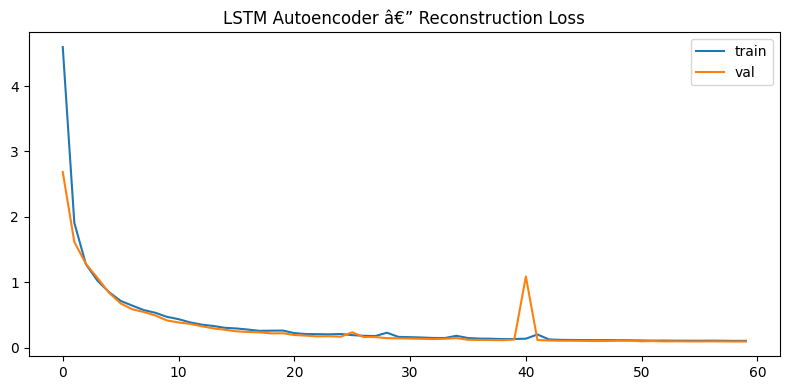

In [15]:
X_tr_ae, X_val_ae = train_test_split(X_train_ae, test_size=0.15, shuffle=False)

es_ae = callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
lr_ae = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)

history_ae = autoencoder.fit(
    X_tr_ae, X_tr_ae,
    validation_data=(X_val_ae, X_val_ae),
    epochs=60, batch_size=128,
    callbacks=[es_ae, lr_ae], verbose=1,
)

plt.figure(figsize=(8,4))
plt.plot(history_ae.history["loss"], label="train")
plt.plot(history_ae.history["val_loss"], label="val")
plt.title("LSTM Autoencoder â€” Reconstruction Loss"); plt.legend(); plt.tight_layout(); plt.show()

Threshold (IQR) : 0.5608
Threshold (p95) : 0.9874


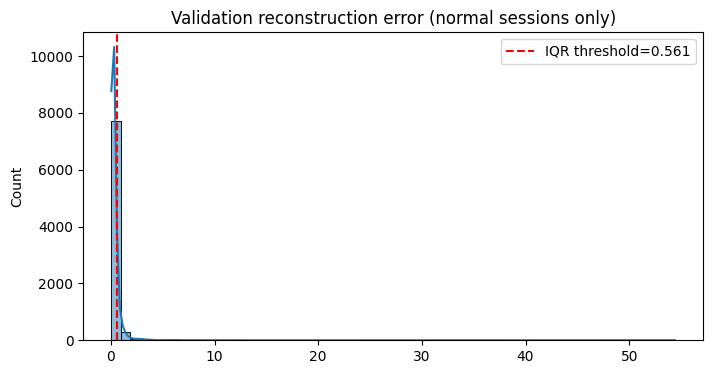

In [16]:
val_pred   = autoencoder.predict(X_val_ae, verbose=0)
# AFTER (isolates the worst moment in the window)
val_errors = np.max(np.mean(np.square(X_val_ae - val_pred), axis=2), axis=1)

Q1, Q3 = np.percentile(val_errors, [25, 75])
IQR     = Q3 - Q1
threshold = float(Q3 + 1.5 * IQR)   # standard Tukey fence
print(f"Threshold (IQR) : {threshold:.4f}")
print(f"Threshold (p95) : {np.percentile(val_errors, 95):.4f}")

with open(f"{artifacts_dir}/anomaly_threshold.json","w") as f:
    json.dump({"threshold": threshold, "Q1": float(Q1), "Q3": float(Q3), "IQR": float(IQR)}, f, indent=2)

plt.figure(figsize=(8,4))
sns.histplot(val_errors, bins=60, kde=True)
plt.axvline(threshold, color="red", linestyle="--", label=f"IQR threshold={threshold:.3f}")
plt.legend(); plt.title("Validation reconstruction error (normal sessions only)"); plt.show()

In [17]:
err_normal  = np.mean(np.square(X_test_normal  - autoencoder.predict(X_test_normal,  verbose=0)), axis=(1,2))
err_anomaly = np.max(np.mean(np.square(X_test_anomaly - autoencoder.predict(X_test_anomaly, verbose=0)), axis=2), axis=1)

all_errors = np.concatenate([err_normal, err_anomaly])
all_labels = np.array([0]*len(err_normal) + [1]*len(err_anomaly))

flags = (all_errors > threshold).astype(int)
tp = ((flags==1) & (all_labels==1)).sum()
fp = ((flags==1) & (all_labels==0)).sum()
fn = ((flags==0) & (all_labels==1)).sum()
precision = tp / max(1, tp+fp)
recall    = tp / max(1, tp+fn)
f1        = 2*precision*recall / max(1e-9, precision+recall)
auc       = roc_auc_score(all_labels, all_errors)

print(f"AUC-ROC   : {auc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1        : {f1:.4f}")

AUC-ROC   : 0.9723
Precision : 0.5663
Recall    : 0.6745
F1        : 0.6157


In [18]:
autoencoder.export(f"{artifacts_dir}/anomaly_lstm_autoencoder")
# !python -m tf2onnx.convert --saved-model artifacts/anomaly_lstm_autoencoder \
#   --output artifacts/anomaly_lstm_autoencoder.onnx

#  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•—  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•— â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•— â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•—     â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•—
#  â–ˆâ–ˆâ•”â•â•â–ˆâ–ˆâ•—â–ˆâ–ˆâ•”â•â•â–ˆâ–ˆâ•—â–ˆâ–ˆâ•”â•â•â–ˆâ–ˆâ•—â•šâ•â•â–ˆâ–ˆâ•”â•â•â•    â–ˆâ–ˆâ•”â•â•â–ˆâ–ˆâ•—
#  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•”â•â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•‘â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•”â•   â–ˆâ–ˆâ•‘       â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•”â•
#  â–ˆâ–ˆâ•”â•â•â•â• â–ˆâ–ˆâ•”â•â•â–ˆâ–ˆâ•‘â–ˆâ–ˆâ•”â•â•â–ˆâ–ˆâ•—   â–ˆâ–ˆâ•‘       â–ˆâ–ˆâ•”â•â•â–ˆâ–ˆâ•—
#  â–ˆâ–ˆâ•‘     â–ˆâ–ˆâ•‘  â–ˆâ–ˆâ•‘â–ˆâ–ˆâ•‘  â–ˆâ–ˆâ•‘   â–ˆâ–ˆâ•‘       â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•”â•
#  â•šâ•â•     â•šâ•â•  â•šâ•â•â•šâ•â•  â•šâ•â•   â•šâ•â•       â•šâ•â•â•â•â•â•
#  GRU â€” Next-Action Prediction

Saved artifact at 'artifacts/anomaly_lstm_autoencoder'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10, 22), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10, 22), dtype=tf.float32, name=None)
Captures:
  136990380077328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136990380080976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136990380077904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136990380078288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136990380074448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136990380074064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136990380067536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136990380075600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136990380075216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136990380067344: TensorSpec(shape=(), dtype=tf.resource, name=None

In [19]:
num_actions = len(action_le.classes_)
classes_present = np.unique(y_train)
raw_weights = compute_class_weight("balanced", classes=classes_present, y=y_train)
raw_weights = np.clip(raw_weights, 0.1, 10.0)
class_weight_dict = {int(c): float(w) for c,w in zip(classes_present, raw_weights)}
for c in range(num_actions):
    class_weight_dict.setdefault(c, 1.0)
print(f"Class weights computed for {len(class_weight_dict)} classes.")

Class weights computed for 43 classes.


In [20]:
gru_in = layers.Input(shape=(SEQ_LEN, input_dim))
gx = layers.Masking(mask_value=0.0)(gru_in)
gx = layers.Bidirectional(layers.GRU(128, return_sequences=True))(gx)
gx = layers.Dropout(0.30)(gx)
gx = layers.Bidirectional(layers.GRU(64, return_sequences=False))(gx)
gx = layers.Dropout(0.30)(gx)
gx = layers.Dense(128, activation="relu")(gx)
gx = layers.Dropout(0.20)(gx)
gru_out = layers.Dense(num_actions, activation="softmax")(gx)

gru_model = models.Model(gru_in, gru_out, name="gru_next_action")
gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(5e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
gru_model.summary()

Model: "gru_next_action"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 10, 22)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 10, 22)    │          0 │ input_layer_1[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_1 (Masking) │ (None, 10, 22)    │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_1 (Any)         │ (None, 10)        │          0 │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 10, 256)   │    116,736 │ masking_1[0][0],  │
│ (Bidirectional)     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 10, 256)   │          0 │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 128)       │    123,648 │ dropout_2[0][0],  │
│ (Bidirectional)     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ bidirectional_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     16,512 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 43)        │      5,547 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 262,443 (1.00 MB)

 Trainable params: 262,443 (1.00 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
X_tr_gru, X_val_gru, y_tr_gru, y_val_gru = train_test_split(
    X_train, y_train, test_size=0.15, shuffle=False)

es_gru = callbacks.EarlyStopping(monitor="val_accuracy", patience=12,
                                  restore_best_weights=True, mode="max")
lr_gru = callbacks.ReduceLROnPlateau(monitor="val_accuracy", factor=0.5,
                                      patience=4, min_lr=1e-6, mode="max")

history_gru = gru_model.fit(
    X_tr_gru, y_tr_gru,
    validation_data=(X_val_gru, y_val_gru),
    epochs=60, batch_size=128,
    class_weight=class_weight_dict,
    callbacks=[es_gru, lr_gru], verbose=1,
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history_gru.history["accuracy"], label="train")
ax1.plot(history_gru.history["val_accuracy"], label="val")
ax1.set_title("GRU Accuracy"); ax1.legend()
ax2.plot(history_gru.history["loss"], label="train")
ax2.plot(history_gru.history["val_loss"], label="val")
ax2.set_title("GRU Loss"); ax2.legend()
plt.tight_layout(); plt.show()

Epoch 1/60
380/380 ━━━━━━━━━━━━━━━━━━━━ 58s 127ms/step - accuracy: 0.1042 - loss: 2.7606 - val_accuracy: 0.1315 - val_loss: 3.1427 - learning_rate: 5.0000e-04
Epoch 2/60
380/380 ━━━━━━━━━━━━━━━━━━━━ 78s 117ms/step - accuracy: 0.1555 - loss: 2.5722 - val_accuracy: 0.1917 - val_loss: 2.9262 - learning_rate: 5.0000e-04
Epoch 3/60
380/380 ━━━━━━━━━━━━━━━━━━━━ 52s 137ms/step - accuracy: 0.1899 - loss: 2.4571 - val_accuracy: 0.1998 - val_loss: 2.7948 - learning_rate: 5.0000e-04
Epoch 4/60
380/380 ━━━━━━━━━━━━━━━━━━━━ 44s 115ms/step - accuracy: 0.2246 - loss: 2.3509 - val_accuracy: 0.2579 - val_loss: 2.6274 - learning_rate: 5.0000e-04
Epoch 5/60
380/380 ━━━━━━━━━━━━━━━━━━━━ 44s 115ms/step - accuracy: 0.2601 - loss: 2.2794 - val_accuracy: 0.3142 - val_loss: 2.5295 - learning_rate: 5.0000e-04
Epoch 6/60
380/380 ━━━━━━━━━━━━━━━━━━━━ 83s 118ms/step - accuracy: 0.2986 - loss: 2.2145 - val_accuracy: 0.3249 - val_loss: 2.4126 - learning_rate: 5.0000e-04
Epoch 7/60
380/380 ━━━━━━━━━━━━━━━━━━━━ 65s 17

In [ ]:
y_prob = gru_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average="macro", zero_division=0)
print(f"Top-1 Accuracy : {acc:.4f}")
print(f"Macro-F1       : {f1:.4f}")

def top_k_accuracy(y_true, y_prob, k):
    topk = np.argsort(y_prob, axis=1)[:, -k:]
    return np.mean([1 if y_true[i] in topk[i] else 0 for i in range(len(y_true))])

for k in [1, 3, 5]:
    print(f"Top-{k} accuracy: {top_k_accuracy(y_test, y_prob, k):.4f}")

# Fixed: Pass explicit labels to ensure target_names match
all_labels = np.arange(len(action_le.classes_))
print(classification_report(y_test, y_pred,
                            labels=all_labels,
                            target_names=action_le.classes_,
                            zero_division=0))

In [ ]:
gru_model.export(f"{artifacts_dir}/next_action_gru")
json.dump({int(i): cls for i,cls in enumerate(action_le.classes_)},
          open(f"{artifacts_dir}/next_action_label_map.json","w"), ensure_ascii=False, indent=2)
# !python -m tf2onnx.convert --saved-model artifacts/next_action_gru \
#   --output artifacts/next_action_gru.onnx --opset 13

#  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•—  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•— â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•— â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•—      â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•—
#  â–ˆâ–ˆâ•”â•â•â–ˆâ–ˆâ•—â–ˆâ–ˆâ•”â•â•â–ˆâ–ˆâ•—â–ˆâ–ˆâ•”â•â•â–ˆâ–ˆâ•—â•šâ•â•â–ˆâ–ˆâ•”â•â•â•     â–ˆâ–ˆâ•”â•â•â•â•â•
#  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•”â•â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•‘â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•”â•   â–ˆâ–ˆâ•‘        â–ˆâ–ˆâ•‘
#  â–ˆâ–ˆâ•”â•â•â•â• â–ˆâ–ˆâ•”â•â•â–ˆâ–ˆâ•‘â–ˆâ–ˆâ•”â•â•â–ˆâ–ˆâ•—   â–ˆâ–ˆâ•‘        â–ˆâ–ˆâ•‘
#  â–ˆâ–ˆâ•‘     â–ˆâ–ˆâ•‘  â–ˆâ–ˆâ•‘â–ˆâ–ˆâ•‘  â–ˆâ–ˆâ•‘   â–ˆâ–ˆâ•‘        â•šâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•—
#  â•šâ•â•     â•šâ•â•  â•šâ•â•â•šâ•â•  â•šâ•â•   â•šâ•â•         â•šâ•â•â•â•â•â•
#  XGBOOST â€” Daily trend forecasting

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

df_daily = df.copy()
df_daily["date"] = df_daily["createdAt"].dt.date
daily_counts = (df_daily.groupby(["date","action"]).size()
                .reset_index(name="count"))
daily_counts["date"]      = pd.to_datetime(daily_counts["date"])
daily_counts["dayofweek"] = daily_counts["date"].dt.dayofweek
daily_counts["month_num"] = daily_counts["date"].dt.month
daily_counts["day"]       = daily_counts["date"].dt.day
daily_counts["is_weekend"]= (daily_counts["dayofweek"]>=5).astype(int)

# Encode action
actl = LabelEncoder()
daily_counts["action_id"] = actl.fit_transform(daily_counts["action"])
daily_counts = daily_counts.sort_values(["action_id","date"]).reset_index(drop=True)

for lag in [1, 2, 3, 7, 14, 30]:
    daily_counts[f"lag_{lag}"] = daily_counts.groupby("action_id")["count"].shift(lag)

daily_counts["rolling_mean_7"] = daily_counts.groupby("action_id")["count"].shift(1).rolling(7).mean()
daily_counts["rolling_std_7"]  = daily_counts.groupby("action_id")["count"].shift(1).rolling(7).std()
daily_counts["rolling_mean_30"]= daily_counts.groupby("action_id")["count"].shift(1).rolling(30).mean()
daily_counts = daily_counts.dropna().reset_index(drop=True)

feature_cols_trend = ["action_id","dayofweek","month_num","day","is_weekend",
                      "lag_1","lag_2","lag_3","lag_7","lag_14","lag_30",
                      "rolling_mean_7","rolling_std_7","rolling_mean_30"]
X_trend  = daily_counts[feature_cols_trend]
y_trend  = daily_counts["count"]
split_tr = int(len(daily_counts)*0.8)
X_tr_t, X_te_t = X_trend.iloc[:split_tr], X_trend.iloc[split_tr:]
y_tr_t, y_te_t = y_trend.iloc[:split_tr], y_trend.iloc[split_tr:]

In [ ]:
trend_model = XGBRegressor(
    n_estimators=600, learning_rate=0.03, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
    early_stopping_rounds=30, eval_metric="mae",
)
trend_model.fit(X_tr_t, y_tr_t, eval_set=[(X_te_t, y_te_t)], verbose=50)

y_pred_t = trend_model.predict(X_te_t)
mae  = mean_absolute_error(y_te_t, y_pred_t)
rmse = math.sqrt(mean_squared_error(y_te_t, y_pred_t))
print(f"XGBoost  MAE  : {mae:.3f}")
print(f"XGBoost  RMSE : {rmse:.3f}")

joblib.dump(trend_model, f"{artifacts_dir}/trend_xgboost.pkl")
json.dump(feature_cols_trend, open(f"{artifacts_dir}/trend_feature_cols.json","w"))

#  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•—  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•— â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•— â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•—    â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•—
#  â–ˆâ–ˆâ•”â•â•â–ˆâ–ˆâ•—â–ˆâ–ˆâ•”â•â•â–ˆâ–ˆâ•—â–ˆâ–ˆâ•”â•â•â–ˆâ–ˆâ•—â•šâ•â•â–ˆâ–ˆâ•”â•â•â•    â–ˆâ–ˆâ•”â•â•â–ˆâ–ˆâ•—
#  â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•”â•â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•‘â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•”â•   â–ˆâ–ˆâ•‘       â–ˆâ–ˆâ•‘  â–ˆâ–ˆâ•‘
#  â–ˆâ–ˆâ•”â•â•â•â• â–ˆâ–ˆâ•”â•â•â–ˆâ–ˆâ•‘â–ˆâ–ˆâ•”â•â•â–ˆâ–ˆâ•—   â–ˆâ–ˆâ•‘       â–ˆâ–ˆâ•‘  â–ˆâ–ˆâ•‘
#  â–ˆâ–ˆâ•‘     â–ˆâ–ˆâ•‘  â–ˆâ–ˆâ•‘â–ˆâ–ˆâ•‘  â–ˆâ–ˆâ•‘   â–ˆâ–ˆâ•‘       â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ•”â•
#  â•šâ•â•     â•šâ•â•  â•šâ•â•â•šâ•â•  â•šâ•â•   â•šâ•â•       â•šâ•â•â•â•â•â•
#  ANOMALY TYPE CLASSIFIER
#
#  Answers: "WHICH TYPE of anomaly is this?"
#  Runs AFTER the LSTM AE has flagged a sequence as anomalous.
#  Trained on labeled anomalous sequences (is_anomaly=1, anomaly_type=X).
#  Produces one of 6 labels â†’ fed to LLM for explanation.

In [ ]:
# â”€â”€ Anomaly Type Classifier â€” data preparation â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Uses SESSION-LEVEL sequences (X_sess_train / X_sess_test, seq_len=15)
# so the model sees the full session in one shot.
# This fixes geo_jump recall and rapid_fire precision compared to step-level.
ANOMALY_TYPES = ["rapid_fire", "unusual_hour", "geo_jump",
                 "repeated_fail", "skip_login", "impossible_seq"]

atype_le = LabelEncoder()
# Fit on the full session-level labels so all 7 classes are known
atype_le.fit(np.append(y_sess_type, ["normal"]))  # ensure "normal" is always present
num_anomaly_classes = len(atype_le.classes_)

y_sess_type_train_enc = atype_le.transform(y_sess_type_train)
y_sess_type_test_enc  = atype_le.transform(y_sess_type_test)

print("Anomaly type classes:", atype_le.classes_)
print("\nClass distribution (full dataset):")
print(pd.Series(y_sess_type).value_counts())
print(f"\nTrain sessions: {len(X_sess_train)}  |  Test sessions: {len(X_sess_test)}")

# Class weights â€” handles the ~95% normal / 5% anomalous imbalance
classes_atype  = np.unique(y_sess_type_train_enc)
raw_w_atype    = compute_class_weight("balanced", classes=classes_atype,
                                       y=y_sess_type_train_enc)
raw_w_atype    = np.clip(raw_w_atype, 0.1, 15.0)
cw_atype       = {int(c): float(w) for c, w in zip(classes_atype, raw_w_atype)}
for c in range(num_anomaly_classes):
    cw_atype.setdefault(c, 1.0)
print("\nClass weights:", {atype_le.classes_[k]: round(v,2) for k,v in cw_atype.items()})


In [ ]:
# â”€â”€ Anomaly Type Classifier model â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Input shape: (SESSION_SEQ_LEN=15, n_features=22)
# This is DIFFERENT from the AE and GRU (seq_len=10).
# Spring Boot must send [1, 15, 22] to this model only.
input_dim_sess = X_sess_train.shape[-1]   # should be 22

tc_in = layers.Input(shape=(SESSION_SEQ_LEN, input_dim_sess))
tx = layers.Masking(mask_value=0.0)(tc_in)
tx = layers.Bidirectional(layers.GRU(128, return_sequences=True))(tx)
tx = layers.Dropout(0.25)(tx)
tx = layers.Bidirectional(layers.GRU(64, return_sequences=False))(tx)
tx = layers.Dropout(0.25)(tx)
tx = layers.Dense(128, activation="relu")(tx)
tx = layers.Dropout(0.20)(tx)
tc_out = layers.Dense(num_anomaly_classes, activation="softmax")(tx)

type_classifier = models.Model(tc_in, tc_out, name="anomaly_type_classifier")
type_classifier.compile(
    optimizer=tf.keras.optimizers.Adam(5e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
type_classifier.summary()
print(f"\nInput shape : (batch, {SESSION_SEQ_LEN}, {input_dim_sess})")
print(f"Output shape: (batch, {num_anomaly_classes})  â†’ {list(atype_le.classes_)}")


In [ ]:
# â”€â”€ Train Type Classifier on session-level sequences â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
X_tr_tc, X_val_tc, y_tr_tc, y_val_tc = train_test_split(
    X_sess_train, y_sess_type_train_enc, test_size=0.15, shuffle=False)

es_tc = callbacks.EarlyStopping(
    monitor="val_accuracy", patience=12, restore_best_weights=True, mode="max")
lr_tc = callbacks.ReduceLROnPlateau(
    monitor="val_accuracy", factor=0.5, patience=4, min_lr=1e-6, mode="max")

history_tc = type_classifier.fit(
    X_tr_tc, y_tr_tc,
    validation_data=(X_val_tc, y_val_tc),
    epochs=60, batch_size=128,
    class_weight=cw_atype,
    callbacks=[es_tc, lr_tc], verbose=1,
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history_tc.history["accuracy"],     label="train")
ax1.plot(history_tc.history["val_accuracy"], label="val")
ax1.set_title("Type Classifier Accuracy â€” session-level"); ax1.legend()
ax2.plot(history_tc.history["loss"],     label="train")
ax2.plot(history_tc.history["val_loss"], label="val")
ax2.set_title("Type Classifier Loss"); ax2.legend()
plt.tight_layout(); plt.show()


In [ ]:
# â”€â”€ Evaluate Type Classifier on session-level test set â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
y_tc_prob = type_classifier.predict(X_sess_test, verbose=0)
y_tc_pred = np.argmax(y_tc_prob, axis=1)

print("Overall accuracy:", accuracy_score(y_sess_type_test_enc, y_tc_pred))
print()
print(classification_report(y_sess_type_test_enc, y_tc_pred,
      target_names=atype_le.classes_, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_sess_type_test_enc, y_tc_pred)
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(cm, display_labels=atype_le.classes_).plot(ax=ax, colorbar=False)
plt.title("Anomaly Type Classifier â€” Confusion Matrix (session-level)")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

# â”€â”€ Evaluate only on truly anomalous sessions â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
normal_label = "UNKNOWN" if "UNKNOWN" in atype_le.classes_ else "normal"
try:
    normal_enc = atype_le.transform([normal_label])[0]
    anomaly_idx = np.where(y_sess_type_test_enc != normal_enc)[0]
except ValueError:
    anomaly_idx = np.array([], dtype=int)

if len(anomaly_idx) > 0:
    y_true_anom = y_sess_type_test_enc[anomaly_idx]
    y_pred_anom = y_tc_pred[anomaly_idx]
    anomaly_classes = [c for c in atype_le.classes_ if c != normal_label]
    anomaly_labels  = [i for i, c in enumerate(atype_le.classes_) if c != normal_label]
    print(f"\nAmong {len(anomaly_idx)} truly anomalous sessions:")
    print(classification_report(y_true_anom, y_pred_anom,
          target_names=anomaly_classes, labels=anomaly_labels, zero_division=0))
else:
    print("No anomalous sessions in test set.")


In [30]:
type_classifier.export(f"{artifacts_dir}/anomaly_type_classifier")
json.dump({int(i): cls for i,cls in enumerate(atype_le.classes_)},
          open(f"{artifacts_dir}/anomaly_type_label_map.json","w"), ensure_ascii=False, indent=2)
# !python -m tf2onnx.convert --saved-model artifacts/anomaly_type_classifier \
#   --output artifacts/anomaly_type_classifier.onnx --opset 13

Saved artifact at 'artifacts/anomaly_type_classifier'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 15, 22), dtype=tf.float32, name='keras_tensor_23')
Output Type:
  TensorSpec(shape=(None, 8), dtype=tf.float32, name=None)
Captures:
  136989955777808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136990188343504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136989955773584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136989955778960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136989955778576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136989955771856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136989955780304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136989955776656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136989955778768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136989955780880: TensorSpec(shape=(), dtype=tf.resource, name=None)
 

In [35]:
def evaluate_on_test_set(csv_path: str):
    if not os.path.exists(csv_path):
        print(f"File {csv_path} not found. Please upload it.")
        return

    df_t = pd.read_csv(csv_path)
    df_t["createdAt"] = pd.to_datetime(df_t["createdAt"], utc=True, errors="coerce")

    text_cols = ["action","type","subType","device","countryCode","city","status","userAgent"]
    for c in text_cols:
        if c in df_t.columns:
            df_t[c] = df_t[c].fillna("UNKNOWN").astype(str)

    if "is_anomaly" not in df_t.columns: df_t["is_anomaly"] = 0
    if "anomaly_type" not in df_t.columns: df_t["anomaly_type"] = "normal"
    df_t["anomaly_type"] = df_t["anomaly_type"].replace(r"^\s*$", np.nan, regex=True)
    df_t["anomaly_type"] = df_t["anomaly_type"].replace("UNKNOWN", np.nan)
    df_t["anomaly_type"] = df_t["anomaly_type"].fillna("normal").astype(str)
    df_t.loc[df_t["is_anomaly"] == 0, "anomaly_type"] = "normal"

    # Encoders
    def safe_transform(le, series):
        classes_set = set(le.classes_)
        return np.array([le.transform([v])[0] if v in classes_set else 0 for v in series])

    df_t["action_id"]  = safe_transform(action_le,  df_t["action"])
    df_t["device_id"]  = safe_transform(device_le,  df_t["device"])
    df_t["country_id"] = safe_transform(country_le, df_t["countryCode"])
    df_t["type_id"]    = safe_transform(type_le,    df_t["type"])
    df_t["subType_filled"] = df_t["subType"].fillna("NONE")
    df_t["subtype_id"] = safe_transform(subtype_le, df_t["subType_filled"])

    # Time Features
    df_t["hour_sin"]  = np.sin(2*np.pi*df_t["createdAt"].dt.hour/24)
    df_t["hour_cos"]  = np.cos(2*np.pi*df_t["createdAt"].dt.hour/24)
    df_t["dow_sin"]   = np.sin(2*np.pi*df_t["createdAt"].dt.dayofweek/7)
    df_t["dow_cos"]   = np.cos(2*np.pi*df_t["createdAt"].dt.dayofweek/7)
    df_t["month_num"] = df_t["createdAt"].dt.month
    df_t["is_ok"]     = (df_t["status"]=="OK").astype(int)
    df_t["is_ko"]     = (df_t["status"]=="KO").astype(int)

    # Session signals
    SK = ["insuredId","sessionNumber"]
    df_t = df_t.sort_values(SK + ["sequenceInSession"])
    df_t["prev_time"] = df_t.groupby(SK)["createdAt"].shift(1)
    df_t["delta_seconds_clipped"] = (df_t["createdAt"]-df_t["prev_time"]).dt.total_seconds().fillna(0).clip(0, 3600)

    # Fix: Use same column name as fit time for the scaler
    df_t["delta_scaled"] = scaler_delta.transform(df_t[["delta_seconds_clipped"]])

    if "sessionLength" not in df_t.columns:
        df_t["sessionLength"] = df_t.groupby(SK)["sequenceInSession"].transform("max")

    df_t["seq_pos_norm"]     = df_t["sequenceInSession"] / df_t["sessionLength"]
    df_t["is_session_start"] = (df_t["sequenceInSession"].astype(int)==1).astype(int)
    df_t["is_session_end"]   = (df_t["sequenceInSession"]==df_t["sessionLength"]).astype(int)
    df_t["prev_action_id"]   = (df_t.groupby(SK)["action_id"].shift(1).fillna(-1).astype(int)+1)
    df_t["ko_count_so_far"]  = (df_t.groupby(SK)["is_ko"].cumsum().shift(1).fillna(0).astype(int))
    df_t["session_len_norm"] = df_t["sessionLength"] / max_session_len

    # Geo / Rapid signals
    df_t["ip_prev"]    = df_t.groupby(SK)["ip"].shift(1)
    df_t["ip_changed"] = ((df_t["ip"]!=df_t["ip_prev"]) & df_t["ip_prev"].notna()).astype(int)
    df_t["had_ip_change"] = df_t.groupby(SK)["ip_changed"].cummax()
    df_t["min_delta_so_far"] = df_t.groupby(SK)["delta_seconds_clipped"].cummin().shift(1).fillna(df_t["delta_seconds_clipped"])

    # Build sequences for AE/GRU (seq_len=10) - Unpack 6 values as per function definition
    X_ext, _, y_anom_ext, y_type_ext, _, _ = build_sequences(df_t, SEQ_LEN, include_anomaly_label=True)

    # AE Binary Detection
    preds_ae  = autoencoder.predict(X_ext, verbose=0)
    # Calculate per-step error then take window max
    errors_ae = np.max(np.mean(np.square(X_ext - preds_ae), axis=2), axis=1)
    flags_ae  = (errors_ae > threshold).astype(int)

    print("="*50)
    print("DETECTION PERFORMANCE")
    print(f"Flagged: {flags_ae.sum()}/{len(flags_ae)} sequences")
    if len(np.unique(y_anom_ext)) > 1:
        print(f"AUC-ROC: {roc_auc_score(y_anom_ext, errors_ae):.4f}")

    # Type Classification (uses full sessions)
    X_s, y_s_type, _ = build_sequences_session_level(df_t, SESSION_SEQ_LEN)
    preds_tc = type_classifier.predict(X_s, verbose=0)
    labels_tc = np.argmax(preds_tc, axis=1)

    y_s_enc = safe_transform(atype_le, y_s_type)
    print("\nANOMALY TYPE CLASSIFICATION (Session Level)")
    # Fixed: Specify labels to avoid target_names mismatch when some classes are missing from test set
    all_labels = np.arange(len(atype_le.classes_))
    print(classification_report(y_s_enc, labels_tc, labels=all_labels, target_names=atype_le.classes_, zero_division=0))

evaluate_on_test_set("anomaly_test_set.csv")

DETECTION PERFORMANCE
Flagged: 6066/14150 sequences
AUC-ROC: 0.8207

ANOMALY TYPE CLASSIFICATION (Session Level)
                precision    recall  f1-score   support

       UNKNOWN       1.00      0.99      0.99      1800
      geo_jump       0.79      0.96      0.87       300
impossible_seq       0.98      1.00      0.99       300
        normal       0.00      0.00      0.00         0
    rapid_fire       0.92      0.74      0.82       300
 repeated_fail       1.00      1.00      1.00       300
    skip_login       1.00      1.00      1.00       300
  unusual_hour       0.99      1.00      1.00       300

      accuracy                           0.97      3600
     macro avg       0.83      0.84      0.83      3600
  weighted avg       0.97      0.97      0.97      3600



In [36]:
# The outputs from the 4 models flow into your LLM like this:

LLM_PROMPT_TEMPLATE = """
You are a security analyst for a health insurance self-service portal.

SESSION SUMMARY:
  User: {insured_id}
  Device: {device}
  Country: {country}
  Session start: {session_start}
  Session length: {session_length} actions

ACTION SEQUENCE (last {seq_len} steps):
{action_sequence}

MODEL OUTPUTS:
  LSTM Autoencoder reconstruction error : {ae_score:.4f}  (threshold: {ae_threshold:.4f})
  Anomaly detected                       : {is_anomaly}
  Anomaly type (classifier)              : {anomaly_type}
  Confidence                             : {confidence:.1%}

  Next-action prediction (GRU top-3)    : {next_actions}

TASK:
1. Explain in plain French what anomaly type "{anomaly_type}" means in this context.
2. Describe the risk level (low / medium / high) with justification.
3. Suggest one concrete action the security team should take.
"""

print("LLM prompt template ready.")
print("\nAll models saved to artifacts/:")
import os
for f in sorted(os.listdir("artifacts")):
    print(f"  {f}")

LLM prompt template ready.

All models saved to artifacts/:
  action_vocab.json
  anomaly_lstm_autoencoder
  anomaly_threshold.json
  anomaly_type_classifier
  anomaly_type_label_map.json
  country_vocab.json
  device_vocab.json
  feature_config.json
  next_action_gru
  next_action_label_map.json
  scaler_delta.pkl
  subtype_vocab.json
  trend_feature_cols.json
  trend_xgboost.pkl
  type_vocab.json


In [37]:
!pip install -q tf2onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 31.0 MB/s eta 0:00:00


In [40]:
# --- CPU-only ONNX export + Spring Boot bundle ---
import json
import os
import zipfile
from pathlib import Path
import joblib
import tensorflow as tf
import tf2onnx

try:
    from google.colab import files
except Exception:
    files = None

# Force CPU for export consistency
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

artifacts_dir = Path("artifacts")
with (artifacts_dir / "feature_config.json").open("r", encoding="utf-8") as f:
    cfg = json.load(f)

SEQ_LEN = int(cfg["seq_len"])
N_FEATURES = int(cfg["n_features"])
SESSION_SEQ_LEN = 15

# Map models in memory to their expected output names and sequence lengths
model_mapping = [
    (autoencoder, "anomaly_lstm_autoencoder.onnx", SEQ_LEN),
    (gru_model, "next_action_gru.onnx", SEQ_LEN),
    (type_classifier, "anomaly_type_classifier.onnx", SESSION_SEQ_LEN),
]

print("CPU-only ONNX export from memory...")

def convert_model_to_onnx(model_obj, output_name, seq_len):
    output_path = artifacts_dir / output_name
    print(f"  Converting {output_name} [seq_len={seq_len}]...")

    # Use CPU device context for conversion
    with tf.device("/CPU:0"):
        input_spec = (tf.TensorSpec([None, seq_len, N_FEATURES], tf.float32, name="input"),)
        tf2onnx.convert.from_keras(
            model_obj,
            input_signature=input_spec,
            opset=13,
            output_path=str(output_path),
        )
    return output_path.exists()

for m_obj, out_name, s_len in model_mapping:
    success = convert_model_to_onnx(m_obj, out_name, s_len)
    print("    OK" if success else "    FAILED")

# Save XGBoost Trend Model
if "trend_model" in globals():
    trend_model.save_model(str(artifacts_dir / "trend_xgboost.json"))
    joblib.dump(trend_model, artifacts_dir / "trend_xgboost.pkl")

# Save Scaler as JSON for Java consumption
if "scaler_delta" in globals():
    with (artifacts_dir / "scaler_delta.json").open("w", encoding="utf-8") as f:
        json.dump(
            {"mean": list(scaler_delta.mean_), "scale": list(scaler_delta.scale_)},
            f, indent=2
        )

# Bundle everything into a zip
bundle_files = [
    "anomaly_lstm_autoencoder.onnx", "next_action_gru.onnx", "anomaly_type_classifier.onnx",
    "trend_xgboost.json", "trend_xgboost.pkl", "trend_feature_cols.json",
    "feature_config.json", "anomaly_threshold.json", "next_action_label_map.json",
    "anomaly_type_label_map.json", "action_vocab.json", "device_vocab.json",
    "country_vocab.json", "type_vocab.json", "subtype_vocab.json", "scaler_delta.json", "scaler_delta.pkl"
]

present_paths = [artifacts_dir / f for f in bundle_files if (artifacts_dir / f).exists()]
bundle_zip = Path("springboot_models_bundle_cpu.zip")

with zipfile.ZipFile(bundle_zip, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for path in present_paths:
        zf.write(path, arcname=path.name)

print(f"\nCreated {bundle_zip} with {len(present_paths)} files.")
if files:
    files.download(str(bundle_zip))

CPU-only ONNX export from memory...
  Converting anomaly_lstm_autoencoder.onnx [seq_len=10]...
    OK
  Converting next_action_gru.onnx [seq_len=10]...
    OK
  Converting anomaly_type_classifier.onnx [seq_len=15]...
    OK

Created springboot_models_bundle_cpu.zip with 17 files.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>